In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
df = pd.read_csv('/kaggle/input/image-matching-challenge-2024/sample_submission.csv')
df.head()

,image_path,dataset,scene,rotation_matrix,translation_vector
0,test/church/images/00046.png,church,church,0.9711190310868889;0.8911359604510818;0.532623...,0.11313904678659892;0.8432251602872274;0.42609...
1,test/church/images/00090.png,church,church,0.20360069697426775;0.6504946118853364;0.86491...,0.680480221630539;0.8028143635199276;0.5028546...
2,test/church/images/00092.png,church,church,0.831738872848693;0.5821652805589269;0.6032012...,0.16253346680799086;0.2541505473736173;0.87383...
3,test/church/images/00087.png,church,church,0.1604600521094205;0.6489370807852337;0.721831...,0.2161246142041484;0.9530634517785977;0.449099...
4,test/church/images/00050.png,church,church,0.38660496248295817;0.4015767283826711;0.92385...,0.16786019693458032;0.8533039000844846;0.96215...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   image_path          41 non-null     object
 1   dataset             41 non-null     object
 2   scene               41 non-null     object
 3   rotation_matrix     41 non-null     object
 4   translation_vector  41 non-null     object
dtypes: object(5)
memory usage: 1.7+ KB


In [5]:
df.dtypes

image_path            object
dataset               object
scene                 object
rotation_matrix       object
translation_vector    object
dtype: object

In [6]:
df.columns

Index(['image_path', 'dataset', 'scene', 'rotation_matrix',
       'translation_vector'],
      dtype='object')

In [7]:
df.describe().T

,count,unique,top,freq
image_path,41,41,test/church/images/00046.png,1
dataset,41,1,church,41
scene,41,1,church,41
rotation_matrix,41,41,0.9417813898288877;0.9971452336549242;0.356878...,1
translation_vector,41,41,0.24507112590146185;0.1719143229571507;0.68870...,1


In [9]:
df.isnull().sum()/len('df')*100

image_path            0.0
dataset               0.0
scene                 0.0
rotation_matrix       0.0
translation_vector    0.0
dtype: float64

In [10]:
df.shape

(41, 5)

In [11]:
df.skew

<bound method DataFrame.skew of                       image_path dataset   scene  \
0   test/church/images/00046.png  church  church   
1   test/church/images/00090.png  church  church   
2   test/church/images/00092.png  church  church   
3   test/church/images/00087.png  church  church   
4   test/church/images/00050.png  church  church   
5   test/church/images/00068.png  church  church   
6   test/church/images/00083.png  church  church   
7   test/church/images/00096.png  church  church   
8   test/church/images/00069.png  church  church   
9   test/church/images/00081.png  church  church   
10  test/church/images/00042.png  church  church   
11  test/church/images/00018.png  church  church   
12  test/church/images/00030.png  church  church   
13  test/church/images/00024.png  church  church   
14  test/church/images/00032.png  church  church   
15  test/church/images/00026.png  church  church   
16  test/church/images/00037.png  church  church   
17  test/church/images/00008.png

In [13]:
df.kurt

<bound method DataFrame.kurt of                       image_path dataset   scene  \
0   test/church/images/00046.png  church  church   
1   test/church/images/00090.png  church  church   
2   test/church/images/00092.png  church  church   
3   test/church/images/00087.png  church  church   
4   test/church/images/00050.png  church  church   
5   test/church/images/00068.png  church  church   
6   test/church/images/00083.png  church  church   
7   test/church/images/00096.png  church  church   
8   test/church/images/00069.png  church  church   
9   test/church/images/00081.png  church  church   
10  test/church/images/00042.png  church  church   
11  test/church/images/00018.png  church  church   
12  test/church/images/00030.png  church  church   
13  test/church/images/00024.png  church  church   
14  test/church/images/00032.png  church  church   
15  test/church/images/00026.png  church  church   
16  test/church/images/00037.png  church  church   
17  test/church/images/00008.png

<Axes: >

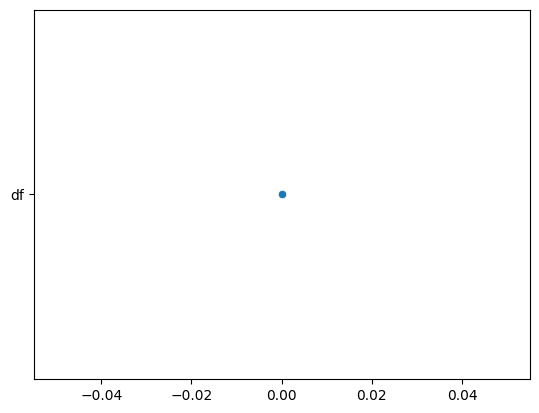

In [16]:
sns.scatterplot('df')

In [3]:
cat_cols = df.select_dtypes(include='object')

In [7]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*15)

image_path



dataset



scene



rotation_matrix



translation_vector





In [9]:
num_cols = df.select_dtypes(include='number')

In [10]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)
    

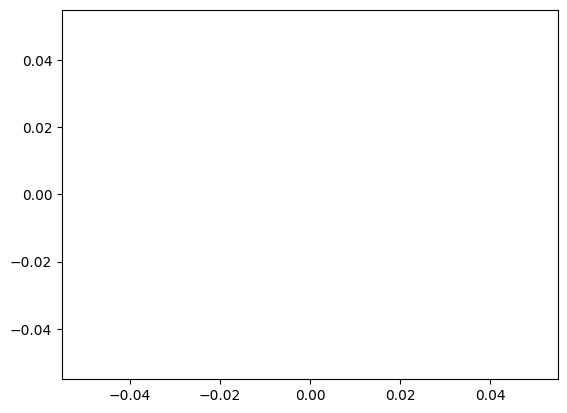

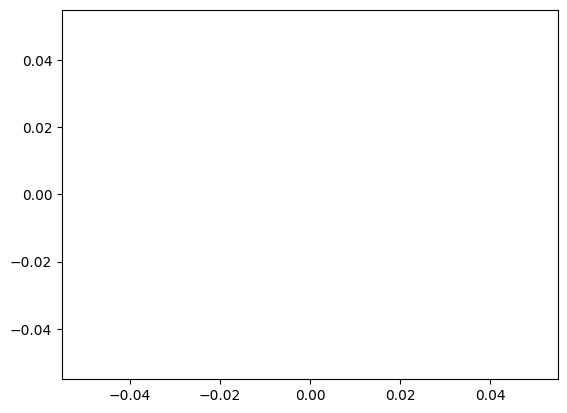

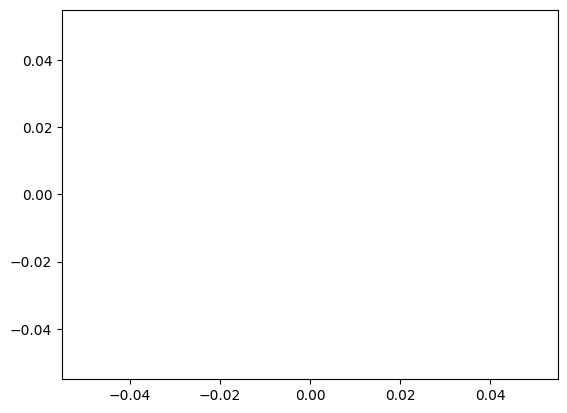

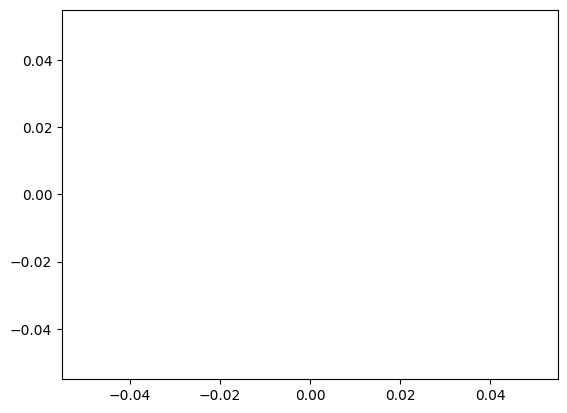

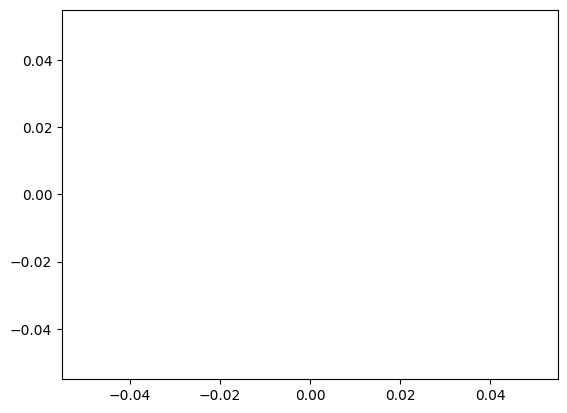

In [18]:
x = 1
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=df)
    print('\n')
    plt.show()